In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

#         Token Index
#           [B, T]
#             │
#             ▼ Transpose + One-Hot
#         [T, B, V]
#             │
#             ▼ Deep RNN / Deep GRU
#         [T, B, H]
#             │
#             ▼ Output Linear Layer
#        [T × B, V]
#             │
#             ▼ Cross-Entropy
#     Next Token Prediction

In [ ]:
# Concise Multilayer GRU

#    <Gate Recurrent Unit>
#      Input:[T, B, V]
#             │
#             ▼
#         GRU Layer 0
#         [T, B, H]
#             │
#             ▼
#         GRU Layer 1
#         [T, B, H]

class GRU(d2l.RNN):
    def __init__(
        self,
        num_inputs: int,  # D
        num_hiddens: int, # H
        num_layers: int,  # L
        dropout: float = 0.0,
    ) -> None:
        d2l.Module.__init__(self)
        
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.rnn = nn.GRU(
            input_size=num_inputs,
            hidden_size=num_hiddens,
            num_layers=num_layers,
            dropout=dropout,
        )

In [18]:
# Multilayer GRU Tensor Shape 확인

num_steps = 3
batch_size = 2
num_inputs = 4
num_hiddens = 8
num_layers = 2

# [T, B, D]
X = torch.randn(
    num_steps,
    batch_size,
    num_inputs,
)

gru = GRU(
    num_inputs=num_inputs,
    num_hiddens=num_hiddens,
    num_layers=num_layers,
)

# 1) output: [T, B, H]
#  마지막 Layer의 모든 Time Step Output
#
# 2) final_state: [L, B, H]
#  모든 Layer의 마지막 Hidden State
Y, final_state = gru.rnn(X)

print("Input shape:", tuple(X.shape))
print("Output shape:", tuple(Y.shape))
print(
    "Final state shape:",
    tuple(final_state.shape),
)

Input shape: (3, 2, 4)
Output shape: (3, 2, 8)
Final state shape: (2, 2, 8)


In [19]:
# Time Machine Multilayer GRU 구성

data = d2l.TimeMachine(
    batch_size=1024,
    num_steps=32,
)

gru = GRU(
    num_inputs=len(data.vocab),
    num_hiddens=32,
    num_layers=2,
)

model = d2l.RNNLM(
    gru,
    vocab_size=len(data.vocab),
    lr=2,
)

print("Vocabulary size:", len(data.vocab))
print("Number of GRU layers:", gru.num_layers)
print("Hidden size:", gru.num_hiddens)

Vocabulary size: 28
Number of GRU layers: 2
Hidden size: 32


In [20]:
# Time Machine Multilayer GRU 구성

data = d2l.TimeMachine(
    batch_size=1024,
    num_steps=32,
)

gru = GRU(
    num_inputs=len(data.vocab),
    num_hiddens=32,
    num_layers=2,
)

model = d2l.RNNLM(
    gru,
    vocab_size=len(data.vocab),
    lr=2,
)

print("Vocabulary size:", len(data.vocab))
print("Number of GRU layers:", gru.num_layers)
print("Hidden size:", gru.num_hiddens)

Vocabulary size: 28
Number of GRU layers: 2
Hidden size: 32


In [21]:
# Device Checking

num_gpus = int(
    torch.cuda.is_available()
)

device = torch.device(
    "cuda"
    if num_gpus == 1
    else "cpu"
)

print("Training device:", device)

if num_gpus == 1:
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

Training device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


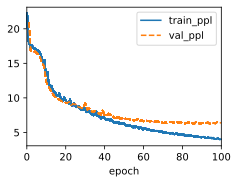

In [ ]:
# Training

trainer = d2l.Trainer(
    max_epochs=100,
    gradient_clip_val=1,
    num_gpus=num_gpus,
)

trainer.fit(
    model,
    data,
)

In [23]:
# Text Generation

prediction = model.predict(
    "it has",
    50,
    data.vocab,
    device,
)

print(prediction)

it has all have a balloon a man and that a said the time
